In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
titanic = sns.load_dataset("titanic")

features = ['pclass','sex','fare','embarked','age']
target = ['survived']


# handle missing data

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])


# encode

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])


X = titanic[features]
Y = titanic["survived"]

# Train Test Split

x_train , x_test , y_train , y_test = train_test_split(
    X,Y , test_size=0.3, random_state=42
)



In [4]:
# Decision Tree

model = DecisionTreeClassifier()

model.fit(x_train,y_train)

y_pred_test = model.predict(x_test)
y_pred_train = model.predict(x_train)

print(f"Training accuracy : {accuracy_score(y_train,y_pred_train)}")
print(f"Testing accuracy : {accuracy_score(y_test,y_pred_test)}")

# classic case of overfitting

Training accuracy : 0.9791332263242376
Testing accuracy : 0.75


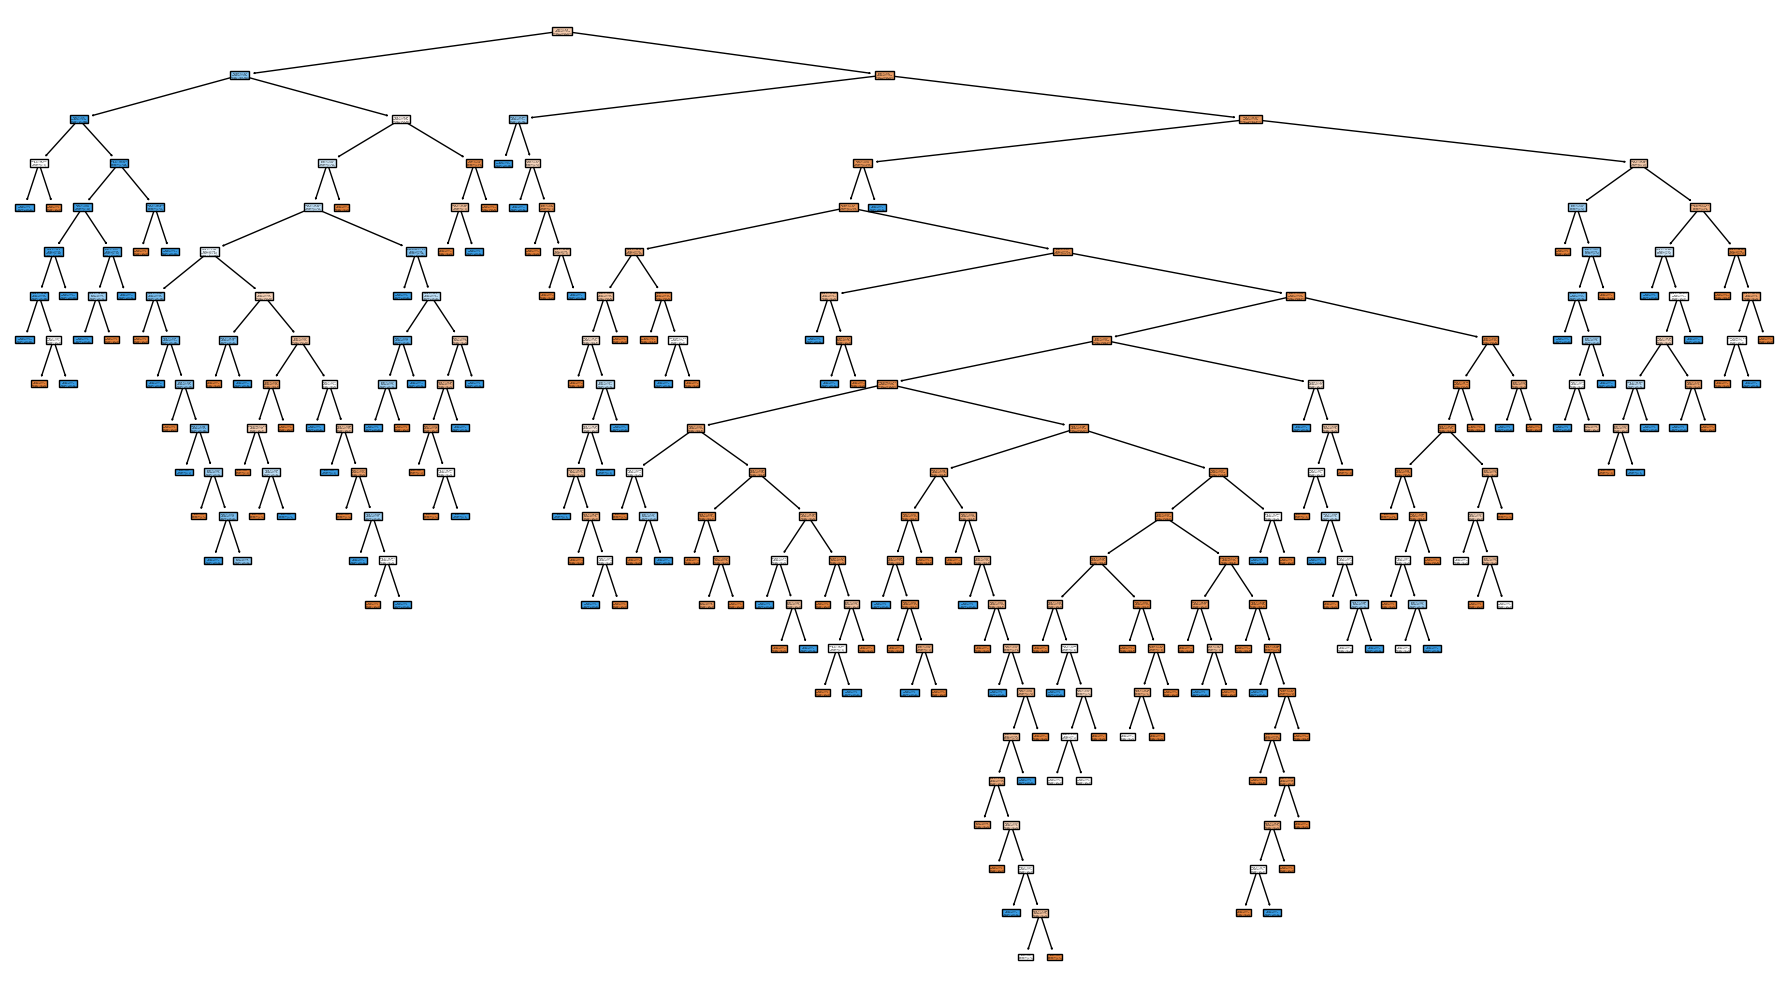

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Died','Survived'],
     filled=True
)
plt.tight_layout()
plt.show()

In [6]:
# Random Forest Classifier 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=201,
    oob_score=True,
    bootstrap=True
)

rf.fit(x_train,y_train)

y_pred = rf.predict(x_test)

print(f"Testing accuracy : {accuracy_score(y_test,y_pred)}")
print(f"OOB Score : {rf.oob_score_}")

Testing accuracy : 0.7761194029850746
OOB Score : 0.8170144462279294


In [14]:
# Bagging Classifier

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    estimator=base_model,
    n_estimators=201,
)

bagging.fit(x_train,y_train)

Y_Pred = bagging.predict(x_test)

print(f"Testing accuracy : {accuracy_score(y_test,Y_Pred)*100} %")

Testing accuracy : 77.98507462686567 %


In [15]:
# Bagging Classifier

from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    estimator=base_model,
    n_estimators=201,
)

bagging.fit(x_train,y_train)

Y_Pred = bagging.predict(x_test)

print(f"Testing accuracy : {accuracy_score(y_test,Y_Pred)*100} %")

Testing accuracy : 79.47761194029852 %
